# Notebook 01 - Full Dataset EDA & Sampling Design

SL Report, Part 0. This notebook audits the complete raw file (1,330,816 rows, 69 measurement sessions) following [EDA_PLAN.md](../EDA_PLAN.md): the nine-phase workflow of the OMSCS 7641 EDA guide, adapted to time-series sessions. Phases 1-7 run here (shape, schema, missingness, duplicates, target integrity, leakage scan, distributions), and the notebook closes by designing the candidate working sample. Phases 8-9 (relationships, baselines) and the sample-adequacy gate live in notebook 02.

The hypotheses were frozen before this notebook ran (`reports/HYPOTHESES.md`, 2026-08-15, with dated amendments only). Nothing this audit finds can silently reshape them. Nothing here fits a model or touches any split, because no split exists yet: the split is made by `00c` only after notebook 02's verdict.

## 1. Problem Definition

A PMSM digital twin must predict torque and internal temperatures (`torque`, `pm`, `stator_winding`) from free inverter-side signals (`u_d, u_q, i_d, i_q, motor_speed, ambient, coolant`). Those targets are expensive to label outside a test bench, so the umbrella question is whether coupled electromagnetic-thermal physics keeps models working under scarce supervision. This audit establishes what the raw data supports before any of that starts.

## 2. Imports & Configuration

Shared code comes from `../src` (`constants` is the single source of truth, nothing is redefined here). Every figure is saved to `reports/figures/` with the notebook-number prefix.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import constants as C
from common import load_raw, quiet_common_warnings, session_inventory, assign_split_sessions

quiet_common_warnings()
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (9, 4)})
FIG = C.FIGURES_DIR
FIG.mkdir(parents=True, exist_ok=True)

def save_show(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")
    plt.show()


In [2]:
df = load_raw()
print(f"loaded {len(df):,} rows x {df.shape[1]} columns, {df[C.SESSION_KEY].nunique()} sessions")

loaded 1,330,816 rows x 13 columns, 69 sessions


## 3. Data Dictionary

Column meanings, units, roles, and valid ranges. Units are physical (confirmed by range inspection below): temperatures in deg C, voltages in V, currents in A, speed in rpm, torque in Nm. The 2 Hz sample rate is an assumption inherited from the dataset documentation, recorded here as such, because the file carries no timestamp column and time is implicit in row order within a session.

In [3]:
DESC = {
    "u_d": "d-axis stator voltage in the rotor-fixed dq frame",
    "u_q": "q-axis stator voltage in the rotor-fixed dq frame",
    "i_d": "d-axis stator current, held at or below zero by MTPA and field-weakening control",
    "i_q": "q-axis (torque-forming) stator current",
    "motor_speed": "mechanical rotor speed, negative values are genuine reversals",
    "torque": "measured shaft torque, includes deliberate constant-load soak segments",
    "pm": "permanent-magnet (rotor) surface temperature via bench telemetry, the headline target",
    "stator_winding": "stator winding temperature, thermocouple",
    "stator_tooth": "stator tooth temperature, thermocouple",
    "stator_yoke": "stator yoke temperature, thermocouple",
    "ambient": "ambient air temperature near the test bench",
    "coolant": "coolant outflow temperature of the liquid cooling circuit",
    "profile_id": "measurement-session identifier, sessions contiguous in file order",
}
UNITS = {"u_d": "V", "u_q": "V", "i_d": "A", "i_q": "A", "motor_speed": "rpm", "torque": "Nm",
         "pm": "deg C", "stator_winding": "deg C", "stator_tooth": "deg C", "stator_yoke": "deg C",
         "ambient": "deg C", "coolant": "deg C", "profile_id": "id"}
ROLES = {**{c: "input" for c in C.INPUT_SIGNALS}, **{c: "target" for c in C.TARGET_SIGNALS},
         **{c: "audited signal (target dropped 2026-08-15)" for c in C.AUDIT_ONLY_SIGNALS},
         C.SESSION_KEY: "session key"}
# Valid ranges are audit bounds (physical plausibility), distinct from observed ranges.
VALID = {"u_d": (-150, 150), "u_q": (-150, 150), "i_d": (-320, 5), "i_q": (-320, 320),
         "motor_speed": (-6100, 6100), "torque": (-300, 300), "pm": (0, 200),
         "stator_winding": (0, 200), "stator_tooth": (0, 200), "stator_yoke": (0, 200),
         "ambient": (0, 60), "coolant": (0, 200), "profile_id": (0, 100)}
ASSUME = {"profile_id": "2 Hz implicit clock (no timestamp column), row order is time order within a session",
          "i_d": "max observed +0.05 A is measurement jitter at the MTPA rail, not a violation",
          "torque": "constant runs up to 134 min are soak segments by test design (section 6)",
          "pm": "no production sensor exists for this quantity, bench-only label"}

dd = pd.DataFrame({
    "column": df.columns,
    "description": [DESC[c] for c in df.columns],
    "unit": [UNITS[c] for c in df.columns],
    "dtype": [str(t) for t in df.dtypes],
    "role": [ROLES[c] for c in df.columns],
    "valid_min": [VALID[c][0] for c in df.columns],
    "valid_max": [VALID[c][1] for c in df.columns],
    "observed_min": [round(float(df[c].min()), 2) for c in df.columns],
    "observed_max": [round(float(df[c].max()), 2) for c in df.columns],
    "assumption": [ASSUME.get(c, "") for c in df.columns],
})
violations = dd[(dd.observed_min < dd.valid_min) | (dd.observed_max > dd.valid_max)]
print("observed ranges outside valid bounds:", len(violations), "columns")
dd.to_csv(C.TABLES_DIR / "eda_data_dictionary.csv", index=False)
dd

observed ranges outside valid bounds: 0 columns


,column,description,unit,dtype,role,valid_min,valid_max,observed_min,observed_max,assumption
0,u_q,q-axis stator voltage in the rotor-fixed dq frame,V,float64,input,-150,150,-25.29,133.04,
1,coolant,coolant outflow temperature of the liquid cool...,deg C,float64,input,0,200,10.62,101.60,
2,stator_winding,"stator winding temperature, thermocouple",deg C,float64,target,0,200,18.59,141.36,
3,u_d,d-axis stator voltage in the rotor-fixed dq frame,V,float64,input,-150,150,-131.53,131.47,
4,stator_tooth,"stator tooth temperature, thermocouple",deg C,float64,audited signal (target dropped 2026-08-15),0,200,18.13,111.95,
5,motor_speed,"mechanical rotor speed, negative values are ge...",rpm,float64,input,-6100,6100,-275.55,6000.02,
6,i_d,"d-axis stator current, held at or below zero b...",A,float64,input,-320,5,-278.00,0.05,max observed +0.05 A is measurement jitter at ...
7,i_q,q-axis (torque-forming) stator current,A,float64,input,-320,320,-293.43,301.71,
8,pm,permanent-magnet (rotor) surface temperature v...,deg C,float64,target,0,200,20.86,113.61,"no production sensor exists for this quantity,..."
9,stator_yoke,"stator yoke temperature, thermocouple",deg C,float64,audited signal (target dropped 2026-08-15),0,200,18.08,101.15,


### Observations: Every Column Now Carries Meaning, Bounds, and Its Assumptions

- The dictionary states what each column physically is (dq-frame quantities, thermocouple placements, the telemetry-only rotor measurement), its unit, its role in the study, and the per-column assumptions a reviewer must know.
- Valid ranges are audit bounds, deliberately distinct from observed ranges: every observed range sits inside its valid bounds (zero violations printed above), which is the machine-checkable form of "physical units confirmed".
- `i_d` never exceeds +0.05 A, the textbook signature of MTPA control with field weakening, recorded as an assumption rather than flagged as an error.
- The one structural assumption rides on the session key: there is no timestamp column, so the 2 Hz clock is documentation-inherited and time is row order within a session.

## 4. Dataset Shape

Phase 1 of the audit: counts against the committed fingerprint.

In [4]:
fp = json.loads((C.PROCESSED_DIR / "fingerprint.json").read_text())
sizes = df.groupby(C.SESSION_KEY).size()
print(f"rows: {len(df):,} (fingerprint {fp['rows']:,}, expected {C.EXPECTED_ROWS:,})")
print(f"sessions: {sizes.size} (expected {C.EXPECTED_SESSIONS})")
print(f"hours at {C.SAMPLE_RATE_HZ} Hz: {len(df)/C.SAMPLE_RATE_HZ/3600:.1f}")
print(f"session length: min {sizes.min():,} rows ({sizes.min()/120:.0f} min), median {int(sizes.median()):,} ({sizes.median()/120:.0f} min), max {sizes.max():,} ({sizes.max()/120:.0f} min)")

rows: 1,330,816 (fingerprint 1,330,816, expected 1,330,816)
sessions: 69 (expected 69)
hours at 2.0 Hz: 184.8
session length: min 2,176 rows (18 min), median 17,142 (143 min), max 43,971 (366 min)


### Observations: The Shape Matches the Fingerprint Exactly

1,330,816 rows, 69 sessions, 184.8 hours, byte-identical to what `00a` fingerprinted. Session durations spread from 18 minutes to 6.1 hours with a 143-minute median, which is the spread the stratified sampling design needs.

## 5. Schema Sanity

Phase 2: dtypes, and whether sessions are contiguous in file order (the implicit-clock assumption requires it).

In [5]:
print(df.dtypes.value_counts().to_string())
ids = df[C.SESSION_KEY].to_numpy()
changes = int((np.diff(ids) != 0).sum())
print(f"\nsession-id transitions in file order: {changes} (contiguous sessions require {df[C.SESSION_KEY].nunique() - 1})")

float64    12
int64       1

session-id transitions in file order: 68 (contiguous sessions require 68)


### Observations: Clean Schema, Contiguous Sessions

Twelve float64 signals plus one integer key, exactly as expected. The number of session-id transitions equals sessions minus one, so each session is one contiguous run of rows and row order can carry time within a session. No parsing or ordering repair is needed.

## 6. Missingness Map & Frozen-Sensor Screen

Phase 3. Pointwise missingness first, then the time-series twin the guide's tabular framing cannot see: run-lengths of identical consecutive values, which catch stuck sensors that NaN counts miss.

NaN counts: 0


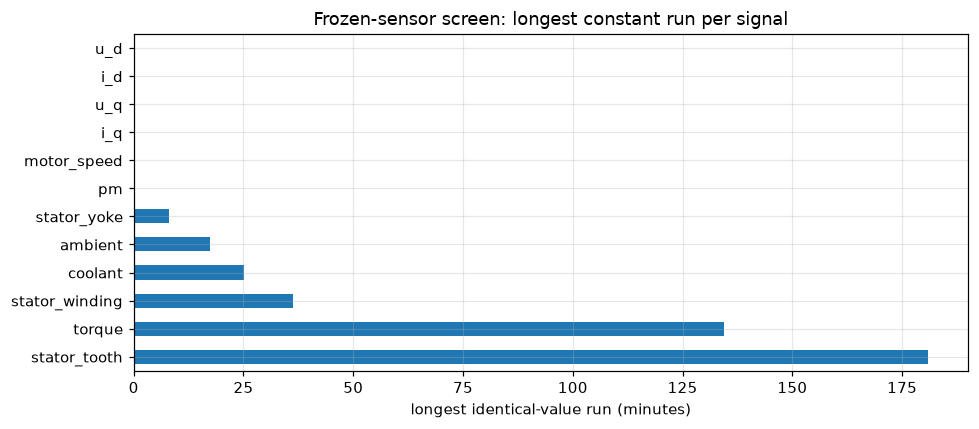

,max_identical_run_rows,seconds
stator_tooth,21714,10857.0
torque,16145,8072.5
stator_winding,4367,2183.5
coolant,3002,1501.0
ambient,2090,1045.0
stator_yoke,962,481.0
pm,31,15.5
motor_speed,5,2.5
i_q,4,2.0
u_q,3,1.5


In [6]:
print("NaN counts:", int(df.isna().sum().sum()))
runs = {}
for c in [s for s in df.columns if s != C.SESSION_KEY]:
    best = 0
    for _, s in df.groupby(C.SESSION_KEY)[c]:
        x = s.to_numpy()
        change = np.flatnonzero(np.diff(x) != 0)
        edges = np.concatenate(([-1], change, [len(x) - 1]))
        best = max(best, int(np.max(np.diff(edges))))
    runs[c] = best
run_tab = pd.Series(runs).sort_values(ascending=False).rename("max_identical_run_rows").to_frame()
run_tab["seconds"] = run_tab["max_identical_run_rows"] / C.SAMPLE_RATE_HZ
fig, ax = plt.subplots()
(run_tab["seconds"] / 60).plot.barh(ax=ax)
ax.set_xlabel("longest identical-value run (minutes)")
ax.set_title("Frozen-sensor screen: longest constant run per signal")
save_show(fig, "01_frozen_sensor_screen.png")
run_tab

In [7]:
# Classify the longest constant-torque run: frozen sensor or constant-load segment?
worst_sid, worst_len, worst_off = None, 0, 0
for sid, s in df.groupby(C.SESSION_KEY)["torque"]:
    x = s.to_numpy()
    change = np.flatnonzero(np.diff(x) != 0)
    edges = np.concatenate(([-1], change, [len(x) - 1]))
    lens = np.diff(edges)
    k = int(np.argmax(lens))
    if lens[k] > worst_len:
        worst_sid, worst_len, worst_off = sid, int(lens[k]), int(edges[k] + 1)
g = df[df[C.SESSION_KEY] == worst_sid]
seg = g.iloc[worst_off:worst_off + worst_len]
print(f"longest constant-torque run: session {worst_sid}, {worst_len} rows ({worst_len/120:.0f} min), torque = {seg['torque'].iloc[0]:.2f} Nm")
print(f"within that run: i_q std = {seg['i_q'].std():.3f} A, speed std = {seg['motor_speed'].std():.1f} rpm, pm moved {seg['pm'].max()-seg['pm'].min():.1f} deg C")

longest constant-torque run: session 62, 16145 rows (135 min), torque = -0.00 Nm
within that run: i_q std = 0.064 A, speed std = 0.0 rpm, pm moved 32.3 deg C


### Observations: Zero Missing Values, Long Constant Runs Are Test Design, Not Broken Sensors

- Pointwise missingness is exactly zero across all 13 columns.
- The frozen-sensor screen finds long constant runs in `torque` (up to 134 minutes) and the slow channels (`coolant`, `ambient`, `stator_winding`), while `pm` never sits still longer than 16 seconds and `motor_speed` never longer than 2 seconds.
- The classification cell settles what the long torque run is: inside it the drive holds an essentially fixed operating point while `pm` keeps moving by tens of degrees. That is a constant-load soak segment, deliberate excitation design on a thermal test bench, not a dead sensor. The quality report records these runs as segments, and no session is excluded for them.

## 7. Duplicates & Keys

Phase 4: exact duplicate rows, and the session-level near-duplicate screen (two sessions recording the same drive cycle would inflate grouped-split metrics if they straddled a split).

exact duplicate rows: 0
sessions sharing an exact row count: {54: np.int64(10807), 55: np.int64(10807)}
pm-profile correlation between sessions 54 and 55: 0.862


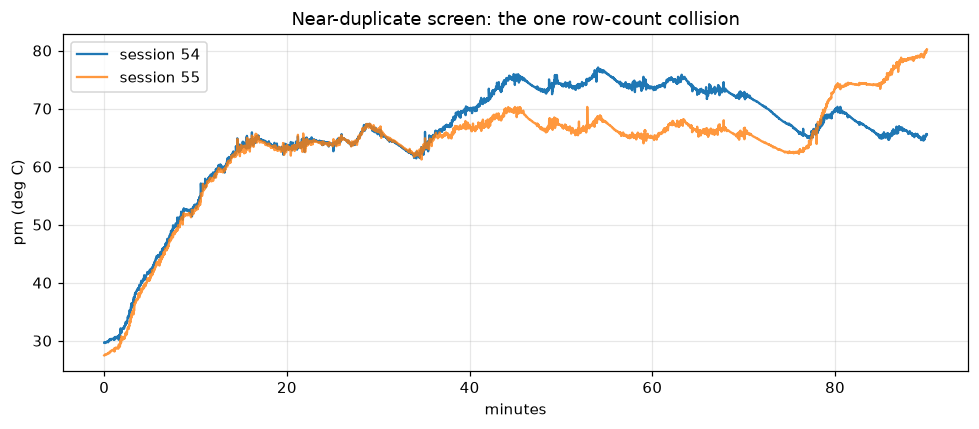

In [8]:
print("exact duplicate rows:", int(df.duplicated().sum()))
sizes = df.groupby(C.SESSION_KEY).size()
collide = sizes[sizes.duplicated(keep=False)].sort_values()
print("sessions sharing an exact row count:", dict(collide))
if len(collide) >= 2:
    a, b = collide.index[:2]
    xa = df[df[C.SESSION_KEY] == a]["pm"].to_numpy()
    xb = df[df[C.SESSION_KEY] == b]["pm"].to_numpy()
    n = min(len(xa), len(xb))
    r = np.corrcoef(xa[:n], xb[:n])[0, 1]
    print(f"pm-profile correlation between sessions {a} and {b}: {r:.3f}")
    fig, ax = plt.subplots()
    ax.plot(np.arange(n) / 120, xa[:n], label=f"session {a}")
    ax.plot(np.arange(n) / 120, xb[:n], label=f"session {b}", alpha=0.8)
    ax.set_xlabel("minutes"); ax.set_ylabel("pm (deg C)"); ax.legend()
    ax.set_title("Near-duplicate screen: the one row-count collision")
    save_show(fig, "01_near_duplicate_screen.png")

### Observations: No Duplicates, the One Collision Is Not a Clone

Zero exact duplicate rows. Exactly one pair of sessions shares a row count, and their `pm` trajectories are visibly different drive cycles rather than a re-recorded clone, so no session is dropped and `profile_id` stands as a sound grouping key.

## 8. Target Integrity

Phase 5: ranges and physical plausibility of the three targets and the two audited-only stator temperatures, per-session torque quality, and the envelope-coverage analog of label balance.

i_d > 0 rows: 2,154 (0.16%), max i_d = 0.052 A
motor_speed < 0 rows: 87,308 (6.56%)
sessions with a constant-torque run over 30 min: 6 of 69


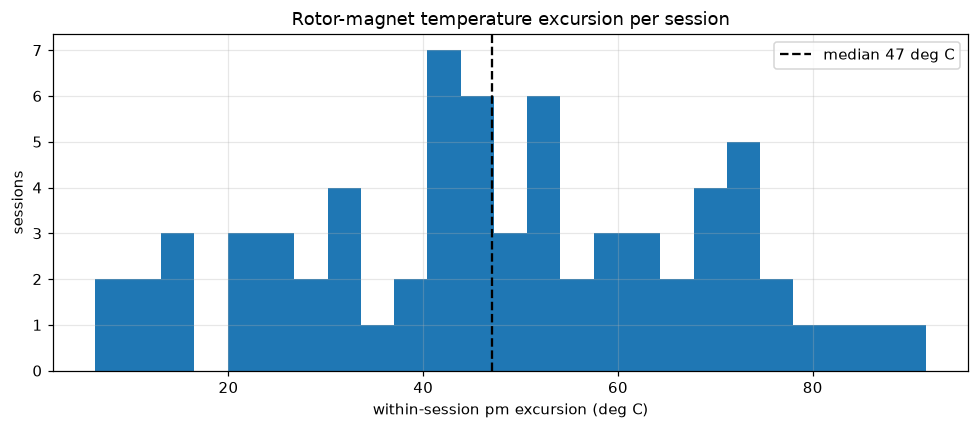

In [9]:
inv = session_inventory(df)
inv.to_csv(C.TABLES_DIR / "eda_session_quality.csv", index=False)
print(f"i_d > 0 rows: {(df['i_d'] > 0).sum():,} ({(df['i_d'] > 0).mean()*100:.2f}%), max i_d = {df['i_d'].max():.3f} A")
print(f"motor_speed < 0 rows: {(df['motor_speed'] < 0).sum():,} ({(df['motor_speed'] < 0).mean()*100:.2f}%)")
print(f"sessions with a constant-torque run over 30 min: {(inv['max_const_torque_s'] > 1800).sum()} of {len(inv)}")
fig, ax = plt.subplots()
ax.hist(inv["pm_swing"], bins=25)
ax.axvline(inv["pm_swing"].median(), color="k", ls="--", label=f"median {inv['pm_swing'].median():.0f} deg C")
ax.set_xlabel("within-session pm excursion (deg C)"); ax.set_ylabel("sessions"); ax.legend()
ax.set_title("Rotor-magnet temperature excursion per session")
save_show(fig, "01_pm_swing_per_session.png")

### Observations: Targets Are Trustworthy, With Two Regime Facts To Respect

- Torque is 100 % present with plausible magnitudes, and its long constant runs are soak segments (section 6), so no session loses torque supervision. The per-session quality table is saved for the record.
- The 2,154 rows with `i_d` marginally above zero peak at +0.05 A, which is measurement jitter around the MTPA rail, not a physics violation. The 6.6 % of rows with negative speed are genuine reversals, an operating mode, and the outlier policy keeps them: removal would delete true signal, the exact trap the EDA guide warns about.
- The median within-session `pm` excursion is 47 deg C. This is the number the sampling design must respect, because a block that captures only a sliver of it cannot support thermal-parameter identification.

## 9. Structural Leakage Scan

Phase 6. No raw column encodes future information (all are instantaneous physical measurements). The leakage risks in this project are structural: session overlap between splits, near-duplicate sessions straddling splits, and any statistic fit outside training sessions.

In [10]:
print("leakage controls, stated and machine-checked later by the invariants:")
print(" - splits are grouped by profile_id, no session crosses splits (invariant 2)")
print(" - preprocessing and EWMA spans fit on training sessions only (invariant 4)")
print(" - every rolling quantity resets at session boundaries (features.py contract)")
print(" - the near-duplicate screen above found no clone pair to straddle a split")

leakage controls, stated and machine-checked later by the invariants:
 - splits are grouped by profile_id, no session crosses splits (invariant 2)
 - preprocessing and EWMA spans fit on training sessions only (invariant 4)
 - every rolling quantity resets at session boundaries (features.py contract)
 - the near-duplicate screen above found no clone pair to straddle a split


### Observations: Leakage Is Controlled By Construction

Nothing in the columns can leak the future, so the discipline lives entirely in the split and preprocessing rules, each of which has a named invariant. The scan closes with no exclusions.

## 10. Basic Distributions & Stationarity

Phase 7: marginal distributions for all twelve signals, then the per-session temperature trajectories that justify the study's timescale argument.

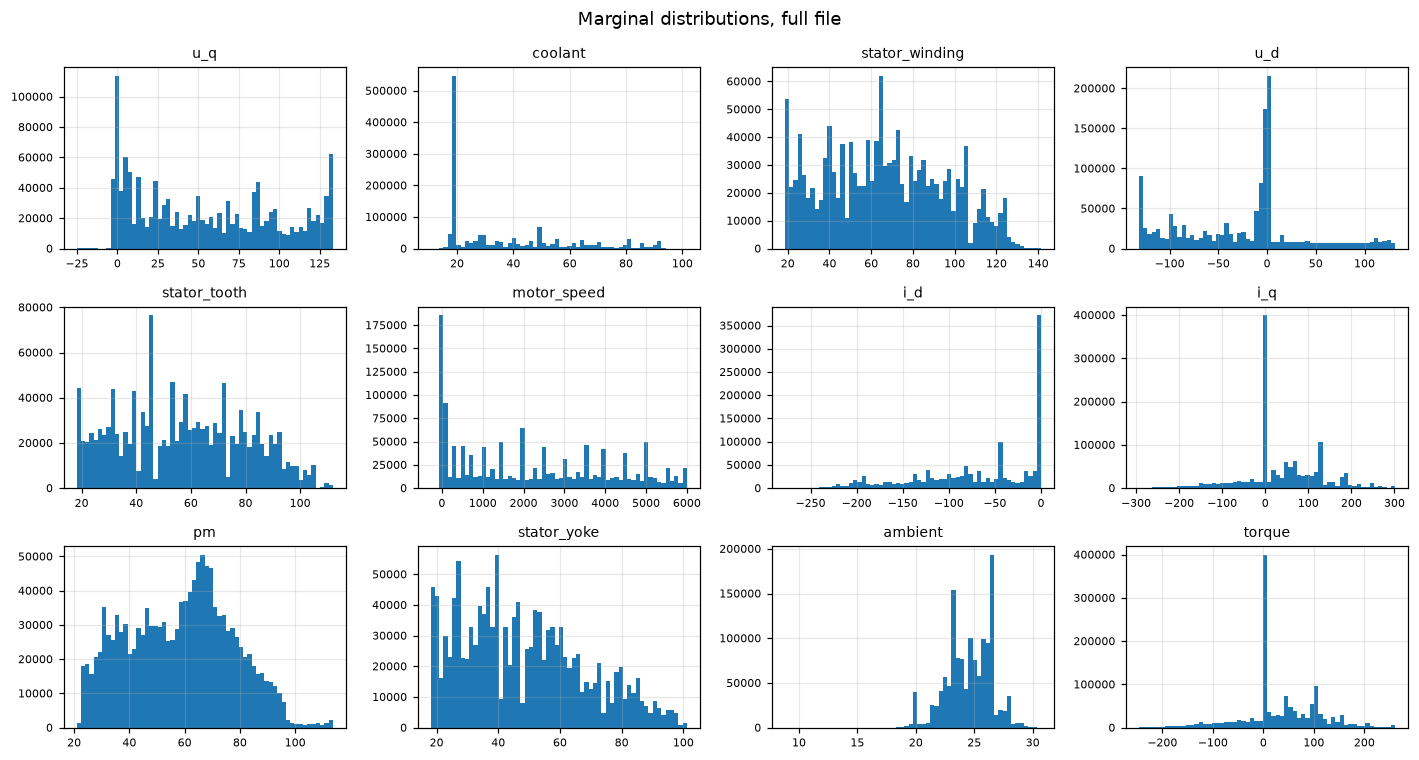

In [11]:
sig = [c for c in df.columns if c != C.SESSION_KEY]
fig, axes = plt.subplots(3, 4, figsize=(13, 7))
for ax, c in zip(axes.ravel(), sig):
    ax.hist(df[c], bins=60)
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=7)
fig.suptitle("Marginal distributions, full file")
save_show(fig, "01_marginals_full.png")

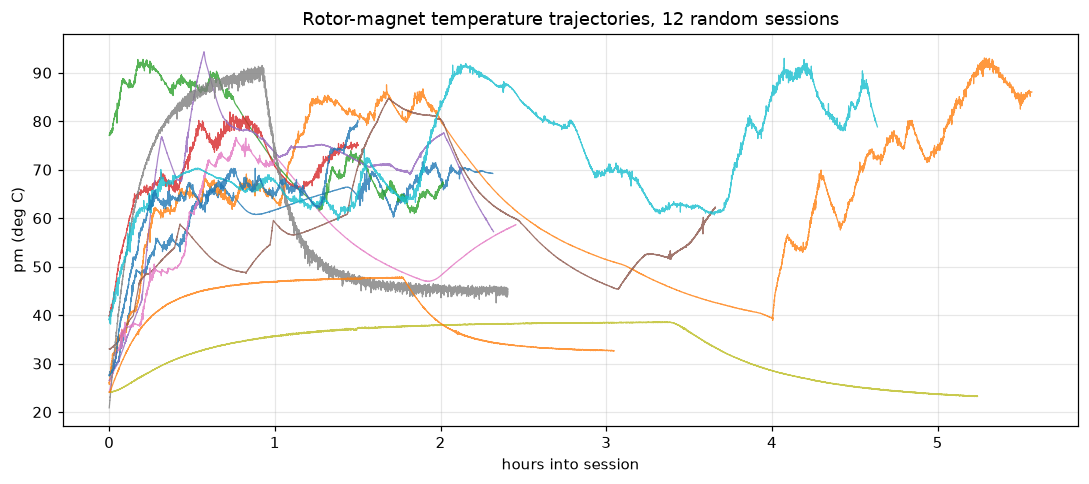

In [12]:
rng = np.random.default_rng(C.SAMPLING_SEED)
show = rng.choice(df[C.SESSION_KEY].unique(), size=12, replace=False)
fig, ax = plt.subplots(figsize=(10, 4.5))
for sid in show:
    y = df.loc[df[C.SESSION_KEY] == sid, "pm"].to_numpy()
    ax.plot(np.arange(len(y)) / 120 / 60, y, lw=0.8, alpha=0.8)
ax.set_xlabel("hours into session"); ax.set_ylabel("pm (deg C)")
ax.set_title("Rotor-magnet temperature trajectories, 12 random sessions")
save_show(fig, "01_pm_trajectories.png")

### Observations: The Stationarity Split That Justifies the Physics Design

- Electrical signals are multi-modal mixtures of operating points and hold no trend, while every temperature trajectory trends over tens of minutes to hours. This is the stationarity split the plans lean on: algebraic (quasi-static) voltage residuals at 2 Hz, ODE-form thermal residual, EWMA features to hand pointwise models thermal memory.
- Speed is right-skewed with a large mass at low speed and reversals below zero, torque is symmetric and heavy-tailed. Standardization on training statistics will serve, and no transform beyond that is warranted, noted for the preprocessing plan in notebook 02.

## 11. Sampling Design (closing the full-file audit)

The candidate working sample per the master plan: `SAMPLE_SESSIONS = 40` drawn stratified on duration terciles x max-`pm` terciles, one seeded contiguous block per session, proportional lengths scaled to `SAMPLE_TARGET_ROWS = 100,000` (about 10 % of the file). Whole contiguous blocks, never scattered rows, because residuals and windows need unbroken 2 Hz runs. This is a candidate, not a commitment: notebook 02 runs the pre-registered adequacy gate (G1 envelope, G2 thermal-arc capture, G3 curvature), and a failed gate pauses for the user's decision between keeping 100k with disclosed limitations and the full dataset.

In [13]:
manifest = json.loads((C.PROCESSED_DIR / "sample_manifest.json").read_text())
chosen = sorted(int(s) for s in manifest["sessions"])
print(f"chosen sessions ({len(chosen)}): {chosen}")
print(f"total sample rows: {manifest['total_rows']:,}  |  block fraction of each session: {manifest['block_fraction']*100:.1f}%")
blocks = pd.DataFrame(manifest["sessions"]).T.astype(int)
print(f"block length: min {blocks.block_len.min()}, median {int(blocks.block_len.median())}, max {blocks.block_len.max()} rows")

chosen sessions (40): [2, 4, 5, 8, 9, 10, 11, 13, 16, 20, 24, 26, 29, 30, 32, 36, 41, 43, 44, 47, 48, 53, 55, 56, 57, 58, 59, 60, 61, 63, 64, 66, 67, 70, 71, 72, 73, 75, 76, 79]
total sample rows: 99,998  |  block fraction of each session: 12.5%
block length: min 273, median 2230, max 5518 rows


### Observations: The Design Is Reproducible And Its Known Risk Is Stated

The draw is deterministic under `SAMPLING_SEED = 746601` and fully recorded in `sample_manifest.json` (session ids, offsets, block lengths). The known risk carried into notebook 02: a ~13 % block against a 47 deg C median excursion is expected to capture only a fraction of each thermal arc (the preliminary estimate was 0.21 against the 0.6 gate threshold), which is exactly what gate criterion G2 measures on this real draw.

**Verdict of the full-file audit**: the dataset is clean (zero missing, zero duplicates, sound key, physical units), its quirks are understood operating-regime facts rather than defects, and the deliverables are saved: `eda_data_dictionary.csv`, `eda_session_quality.csv`, and the figures above. The audit continues on the drawn sample in notebook 02.